<a href="https://colab.research.google.com/github/shxzM/ComputerVision/blob/main/Exp2_AlexNet_EfficientNet_Inception.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sujaradha_thermal_images_diseased_healthy_leaves_paddy_path = kagglehub.dataset_download('sujaradha/thermal-images-diseased-healthy-leaves-paddy')

print('Data source import complete.')


In [ ]:
import os
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision.models import alexnet, inception_v3
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/kaggle/input/thermal-images-diseased-healthy-leaves-paddy/thermal images UL"


transform_alexnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


transform_inception = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


dataset_alexnet = ImageFolder(root=dataset_path, transform=transform_alexnet)

dataset_inception = ImageFolder(root=dataset_path, transform=transform_inception)


def split_dataset(dataset):
    total_size = len(dataset)
    train_size = int(0.6 * total_size)
    val_size = int(0.2 * total_size)
    test_size = total_size - train_size - val_size
    return random_split(dataset, [train_size, val_size, test_size])

train_dataset_alexnet, val_dataset_alexnet, test_dataset_alexnet = split_dataset(dataset_alexnet)
train_dataset_inception, val_dataset_inception, test_dataset_inception = split_dataset(dataset_inception)


def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader_alexnet, val_loader_alexnet, test_loader_alexnet = create_dataloaders(train_dataset_alexnet, val_dataset_alexnet, test_dataset_alexnet)
train_loader_inception, val_loader_inception, test_loader_inception = create_dataloaders(train_dataset_inception, val_dataset_inception, test_dataset_inception)



def train_and_evaluate_model(model, model_name, train_loader, val_loader, test_loader):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)


    train_acc_list = []
    val_acc_list = []


    epochs = 50
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)


        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = 100. * val_correct / val_total
        val_acc_list.append(val_acc)

        print(f"{model_name} | Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


    test_loss = 0.0
    test_correct = 0
    test_total = 0
    model.eval()
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = 100. * test_correct / test_total
    print(f"{model_name} Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy", marker='o')
    plt.plot(range(1, epochs+1), val_acc_list, label="Validation Accuracy", marker='s')
    plt.axhline(y=test_acc, color='r', linestyle='--', label="Test Accuracy")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.title(f"{model_name} Training, Validation, and Test Accuracy")
    plt.show()


num_classes = len(dataset_alexnet.classes)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


AlexNet | Epoch 1/50 | Train Loss: 1.9138 | Train Acc: 24.41% | Val Loss: 1.7822 | Val Acc: 38.58%
AlexNet | Epoch 2/50 | Train Loss: 1.7046 | Train Acc: 26.25% | Val Loss: 1.6947 | Val Acc: 39.37%
AlexNet | Epoch 3/50 | Train Loss: 1.5782 | Train Acc: 38.06% | Val Loss: 1.5831 | Val Acc: 43.31%
AlexNet | Epoch 4/50 | Train Loss: 1.5334 | Train Acc: 39.90% | Val Loss: 1.4468 | Val Acc: 48.03%
AlexNet | Epoch 5/50 | Train Loss: 1.5104 | Train Acc: 40.42% | Val Loss: 1.4561 | Val Acc: 49.61%
AlexNet | Epoch 6/50 | Train Loss: 1.3529 | Train Acc: 44.09% | Val Loss: 1.3372 | Val Acc: 49.61%
AlexNet | Epoch 7/50 | Train Loss: 1.2908 | Train Acc: 46.98% | Val Loss: 1.4389 | Val Acc: 51.97%
AlexNet | Epoch 8/50 | Train Loss: 1.3057 | Train Acc: 49.08% | Val Loss: 1.3631 | Val Acc: 56.69%
AlexNet | Epoch 9/50 | Train Loss: 1.2323 | Train Acc: 47.24% | Val Loss: 1.2696 | Val Acc: 54.33%
AlexNet | Epoch 10/50 | Train Loss: 1.1974 | Train Acc: 53.81% | Val Loss: 1.2803 | Val Acc: 49.61%
AlexNet |

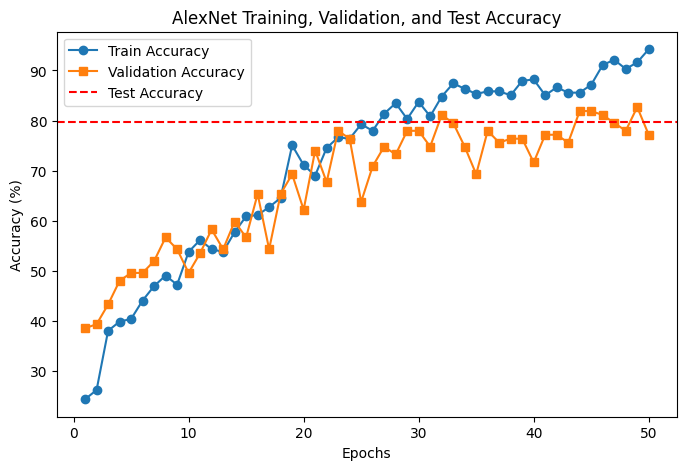

In [ ]:

# AlexNet

alexnet_model = alexnet(pretrained=False)
alexnet_model.classifier[6] = nn.Linear(alexnet_model.classifier[6].in_features, num_classes)
train_and_evaluate_model(alexnet_model, "AlexNet", train_loader_alexnet, val_loader_alexnet, test_loader_alexnet)

/usr/local/lib/python3.10/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Inception V3 | Epoch 1/50 | Train Loss: 1.6333 | Train Acc: 38.32% | Val Loss: 26.3837 | Val Acc: 25.98%
Inception V3 | Epoch 2/50 | Train Loss: 1.2322 | Train Acc: 54.59% | Val Loss: 4.3018 | Val Acc: 17.32%
Inception V3 | Epoch 3/50 | Train Loss: 1.0147 | Train Acc: 63.52% | Val Loss: 1.5077 | Val Acc: 52.76%
Inception V3 | Epoch 4/50 | Train Loss: 0.9349 | Train Acc: 68.50% | Val Loss: 1.3828 | Val Acc: 51.97%
Inception V3 | Epoch 5/50 | Train Loss: 0.7461 | Train Acc: 73.49% | Val Loss: 1.1683 | Val Acc: 60.63%
Inception V3 | Epoch 6/50 | Train Loss: 0.6529 | Train Acc: 76.38% | Val Loss: 1.4566 | Val Acc: 63.78%
Inception V3 | Epoch 7/50 | Train Loss: 0.6205 | Train Acc: 80.05% | Val Loss: 1.2771 | Val Acc: 62.99%
Inception V3 | Epoch 8/50 | Train Loss: 0.6318 | Train Acc: 77.43% | Val Loss: 0.8662 | Val Acc: 70.08%
Inception V3 | Epoch 9/50 | Train Loss: 0.5784 | Train Acc: 78.74% | Val Loss: 1.0526 | Val Acc: 63.78%
Inception V3 | Epoch 10/50 | Train Loss: 0.5564 | Train Acc: 81

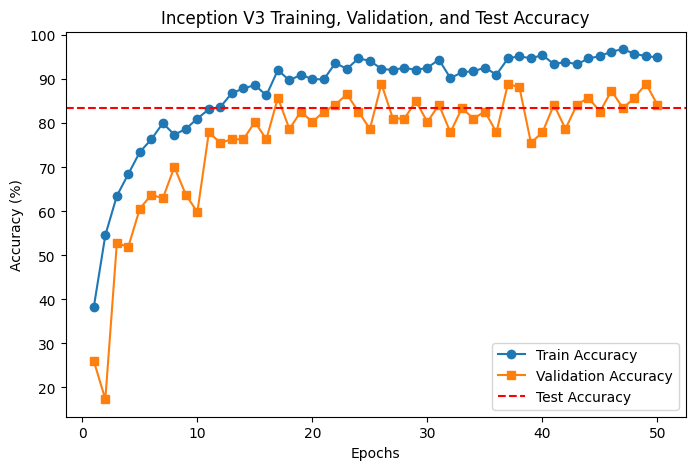

In [ ]:
# Inception V3
num_classes1 = len(dataset_inception.classes)
inception_model = inception_v3(pretrained=False, aux_logits=True)
inception_model.AuxLogits.fc = nn.Linear(inception_model.AuxLogits.fc.in_features, num_classes1)
inception_model.fc = nn.Linear(inception_model.fc.in_features, num_classes)
train_and_evaluate_model(inception_model, "Inception V3", train_loader_inception, val_loader_inception, test_loader_inception)

EfficientNetV2 | Epoch 1/50 | Train Loss: 1.7817 | Train Acc: 23.10% | Val Loss: 1.6749 | Val Acc: 38.58%
EfficientNetV2 | Epoch 2/50 | Train Loss: 1.7056 | Train Acc: 32.55% | Val Loss: 1.6223 | Val Acc: 38.58%
EfficientNetV2 | Epoch 3/50 | Train Loss: 1.5780 | Train Acc: 39.11% | Val Loss: 1.5970 | Val Acc: 38.58%
EfficientNetV2 | Epoch 4/50 | Train Loss: 1.4738 | Train Acc: 39.63% | Val Loss: 1.6177 | Val Acc: 38.58%
EfficientNetV2 | Epoch 5/50 | Train Loss: 1.3601 | Train Acc: 42.78% | Val Loss: 1.4201 | Val Acc: 44.88%
EfficientNetV2 | Epoch 6/50 | Train Loss: 1.4225 | Train Acc: 43.31% | Val Loss: 1.3485 | Val Acc: 51.18%
EfficientNetV2 | Epoch 7/50 | Train Loss: 1.2786 | Train Acc: 49.08% | Val Loss: 1.3255 | Val Acc: 51.97%
EfficientNetV2 | Epoch 8/50 | Train Loss: 1.2928 | Train Acc: 49.61% | Val Loss: 1.4654 | Val Acc: 51.18%
EfficientNetV2 | Epoch 9/50 | Train Loss: 1.3823 | Train Acc: 40.42% | Val Loss: 1.3447 | Val Acc: 55.91%
EfficientNetV2 | Epoch 10/50 | Train Loss: 1.2

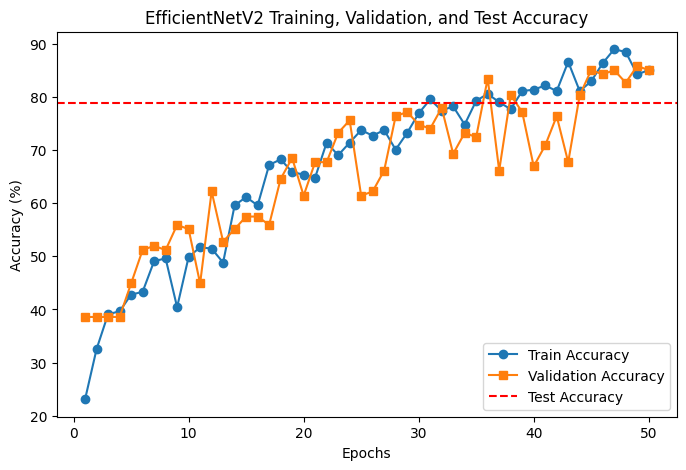

In [ ]:
#EfficientNet
from torchvision.models import efficientnet_v2_s
efficientnet_model = efficientnet_v2_s(pretrained=False)
efficientnet_model.classifier[1] = nn.Linear(efficientnet_model.classifier[1].in_features, num_classes)
train_and_evaluate_model(efficientnet_model, "EfficientNetV2", train_loader_alexnet, val_loader_alexnet, test_loader_alexnet)